# Estimate code-capacity logical error rates

The code-capacity model isolates the code and decoder from circuit faults.
Physical bits or qubits are corrupted independently, while state preparation, syndrome measurement, and correction are treated as perfect.
The benchmark asks how often the sampled error and the decoder's proposed correction combine to form a logical operator.

For a length-$n$ code at physical error rate $p$, the number of corrupted positions (meaning bits or qubits) follows a binomial distribution.
qLDPC samples errors by weight, estimates the decoder's failure probability at each sampled weight, and combines those estimates using the binomial probabilities.
Changing $p$ changes only that final weighting, so one set of decoder samples can estimate a sweep of physical error rates.


## Setup

Run the next cell once in a fresh notebook environment.
IPython's `%pip` magic installs into the active kernel, so the following imports use the same environment.


In [1]:
%%capture
%pip install qldpc matplotlib

In [2]:
from collections.abc import Sequence
from itertools import cycle

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.axes import Axes
from matplotlib.figure import Figure
from sympy.abc import x, y

from qldpc import codes

## One reusable workflow

`get_logical_error_rate_func` samples decoding outcomes and returns a callable estimator.
Evaluating that estimator at one or more physical error rates returns the estimated logical rates and their statistical standard deviations.

The finite sample budget covers only part of the error-weight distribution.
Heavier unsampled errors are conservatively counted as failures, and `truncation_error_bound` reports how much that assumption can raise the estimate.
The shaded band combines one statistical standard deviation with this one-sided truncation bound; it is a diagnostic guide, not an exact confidence interval.


In [3]:
def code_label(code: codes.AbstractCode) -> str:
    """Return a compact code-parameter label for a plot legend."""
    known_distance = code.get_distance_if_known()
    brackets = ("[", "]") if isinstance(code, codes.ClassicalCode) else ("[[", "]]")
    entries = [len(code), code.dimension]
    if known_distance is not None:
        entries.append(known_distance)
    return brackets[0] + ", ".join(map(str, entries)) + brackets[1]


def make_code_capacity_figure(
    codes_to_plot: Sequence[codes.ClassicalCode | codes.QuditCode],
    *,
    error_rates: Sequence[float] = tuple(np.logspace(-2, -0.1, 60)),
    num_samples: int = 10_000,
    figsize: tuple[float, float] = (5.5, 4.2),
    **decoder_kwargs: object,
) -> tuple[Figure, Axes]:
    """Plot estimated code-capacity logical error rates for the requested codes."""
    figure, axis = plt.subplots(figsize=figsize)
    styles = cycle(("o-", "s--", "^-.", "D:"))

    for code_to_plot, style in zip(codes_to_plot, styles):
        estimator = code_to_plot.get_logical_error_rate_func(
            num_samples=num_samples,
            max_error_rate=max(error_rates),
            **decoder_kwargs,
        )
        logical_rates, statistical_error = estimator(error_rates)
        truncation = estimator.truncation_error_bound(error_rates)

        line, *_ = axis.plot(
            error_rates,
            logical_rates,
            style,
            markevery=8,
            label=code_label(code_to_plot),
        )
        axis.fill_between(
            error_rates,
            np.maximum(logical_rates - statistical_error - truncation, 0),
            logical_rates + statistical_error,
            color=line.get_color(),
            alpha=0.18,
        )

    reference_rates = [min(error_rates), max(error_rates)]
    axis.plot(
        reference_rates,
        reference_rates,
        color="black",
        linestyle=":",
        label=r"$p_{\mathrm{logical}}=p_{\mathrm{physical}}$",
    )
    axis.loglog()
    axis.set_xlim(right=1)
    axis.set_ylim(bottom=max(min(error_rates) ** 2, axis.get_ylim()[0]), top=1)
    axis.set_xlabel("physical error rate")
    axis.set_ylabel("estimated logical error rate")
    axis.legend(loc="best")
    axis.grid(which="both", alpha=0.3)
    figure.tight_layout()
    return figure, axis

## Repetition codes

For a repetition code, decoding reduces to a one-dimensional matching problem that minimum-weight perfect matching (MWPM) solves exactly.
At low physical error rates, increasing the code distance suppressses logical failures.
The finite sample budget limits how far down the plot that suppression can be resolved.


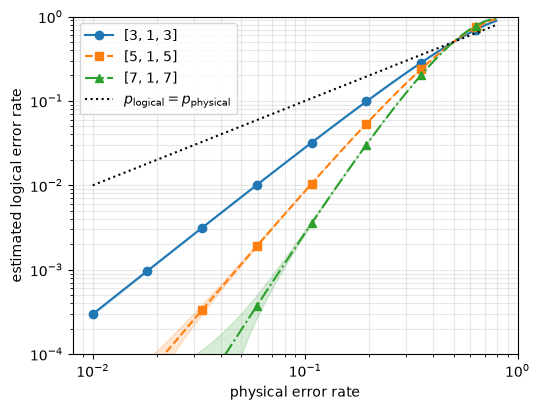

In [4]:
repetition_codes = [codes.RepetitionCode(distance) for distance in (3, 5, 7)]
make_code_capacity_figure(repetition_codes, with_MWPM=True)
plt.show()

The curves separate over the sampled range, while the shaded regions widen where the samples contain little information about the relevant error weights.


## Surface codes

The same workflow accepts quantum CSS codes.
With no Pauli bias supplied, each erroneous qubit receives X, Y, or Z with equal probability.


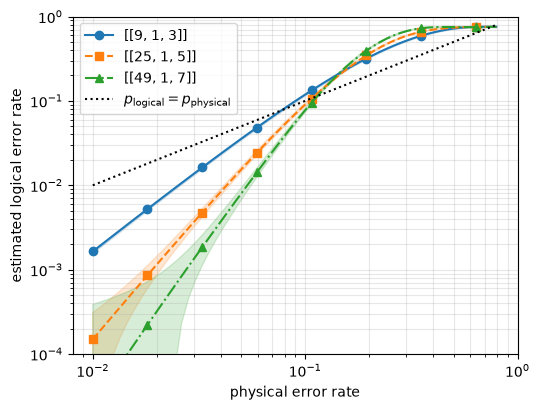

In [5]:
surface_codes = [codes.SurfaceCode(distance) for distance in (3, 5, 7)]
make_code_capacity_figure(surface_codes, with_MWPM=True)
plt.show()

## Bivariate bicycle codes

For this small comparison, BP+LSD replaces MWPM because the bivariate-bicycle checks do not produce a simple matching graph.
The code labels omit distance when qLDPC does not already know an exact value.


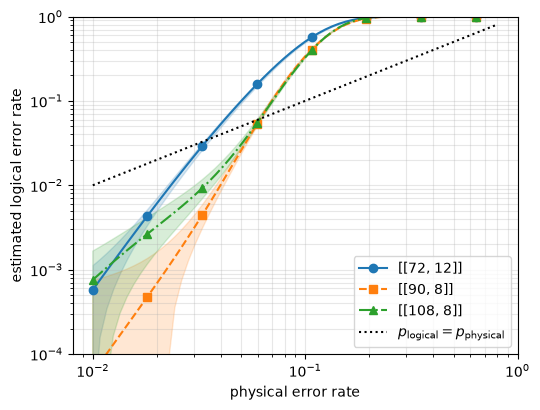

In [6]:
bb_codes = [
    codes.BBCode({x: 6, y: 6}, x**3 + y + y**2, y**3 + x + x**2),
    codes.BBCode({x: 15, y: 3}, x**9 + y + y**2, 1 + x**2 + x**7),
    codes.BBCode({x: 9, y: 6}, x**3 + y + y**2, y**3 + x + x**2),
]
make_code_capacity_figure(bb_codes, with_BP_LSD=True)
plt.show()